# 07 — Index Validation

Independent statistical checks on the CG index construction — does not feed into any
other notebook, and none of the other notebooks depend on it. Re-derives item-level
data straight from `data/raw/numerical_indices.xlsx` and `data/raw/cindex_scores.xlsx`
rather than trusting `06_index_calculation.ipynb`'s in-memory state, and cross-checks
findings against the cleaning rules encoded there (`DROP_IDS`, SEBI weight map).

1. **Data quality & coverage** — missingness, duplicates, coverage gaps
2. **Internal consistency** — Cronbach's alpha, item-total correlations, and
   alpha-if-item-deleted per sub-index
3. **Sub-index relationships** — correlation, multicollinearity, distribution shape,
   and a PCA factor-structure diagnostic (loadings + variance explained only — **no PCA
   composite is constructed or persisted**; see the interpretation note in §3.3)
4. **Robustness & stability** — quarter-to-quarter persistence, hard-break scan, weighting/drop-ID sensitivity
5. **External benchmark comparison** — CG composite vs. an off-the-shelf governance
   classification, where one is available

Note on (2): these are SEBI-compliance checklists, not psychometric scales — each item
is a distinct regulatory requirement, so items aren't expected to move together the way
they would on e.g. a survey measuring one latent trait. Low Cronbach's alpha here is a
description of the construct, not necessarily evidence of a broken index.</cell id="3ca861a6">

In [1]:
import warnings; warnings.filterwarnings('ignore')
import re
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
from statsmodels.stats.outliers_influence import variance_inflation_factor
from statsmodels.stats.stattools import jarque_bera
import statsmodels.api as sm

BASE = Path.cwd()
RAW  = BASE / 'data' / 'raw'
PROC = BASE / 'data' / 'processed'

plt.rcParams.update({'figure.dpi': 120, 'font.size': 10,
                     'axes.spines.top': False, 'axes.spines.right': False})
sns.set_theme(style='whitegrid')

raw = pd.read_excel(RAW / 'numerical_indices.xlsx')
raw['period_end'] = pd.to_datetime(raw['period_end'])

cindex_raw = pd.read_excel(RAW / 'cindex_scores.xlsx')
cindex_raw['period_end'] = pd.to_datetime(cindex_raw['period_end'], errors='coerce')

scores   = pd.read_csv(PROC / 'cg_scores.csv')
matched  = pd.read_excel(PROC / 'matched_companies.xlsx', usecols=['BSE Code', 'NSE Symbol'])
formulas = pd.read_excel(RAW / 'cg_scores_formulas.xlsx', usecols=['ID', 'SEBI'])

# Out-of-sample-derived list (data quality ≥99% non-numeric + hard-break scan +
# FY23-only entity-FE return-association test, t<-1.5) — see
# 06_index_calculation.ipynb's "Out-of-sample metric selection" section for the
# full derivation and the OLD-vs-NEW comparison. B13 replaces A8 relative to the
# old list: A8 is unsupported under the new discipline (only 47.8% missing, zero
# within-firm variation in FY23), while B13 clears the FY23 return-association bar.
DROP_IDS = ["B7", "TR1", "TR2", "TR4", "B13", "B14", "O4"]   # excluded in 06_index_calculation.ipynb

def to_indian_fiscal_quarter(date):
    """Same rule as 06_index_calculation.ipynb."""
    m, y = date.month, date.year
    if m <= 3:       q, fy = 4, y
    elif m <= 6:     q, fy = 1, y + 1
    elif m <= 9:     q, fy = 2, y + 1
    else:            q, fy = 3, y + 1
    return f"Q{q}FY{str(fy)[2:]}"

def q_sort_key(q):
    m = re.match(r'Q(\d)FY(\d+)', str(q))
    return (int(m.group(2)), int(m.group(1))) if m else (9999, 9)

raw['Q_FY'] = raw['period_end'].apply(to_indian_fiscal_quarter)
raw['_numeric_score'] = pd.to_numeric(raw['Score'], errors='coerce')

print(f'Raw numerical_indices: {raw.shape}')
print(f'Raw CINDEX:            {cindex_raw.shape}')
print(f'Processed cg_scores:   {scores.shape}')

Raw numerical_indices: (197800, 13)
Raw CINDEX:            (46310, 10)
Processed cg_scores:   (25520, 7)


In [2]:
# Fix known category mislabel: "O7 — Concentrated ownership type" is filed under
# TRINDEX in the raw scored data, but both its ID prefix and
# cg_scores_formulas.xlsx classify it as OINDEX (flagged by §1.2 below).
# Applied here, independently of 06_index_calculation.ipynb's in-memory state,
# as the same documented correction — before any category-level aggregation,
# so every downstream diagnostic in this notebook uses the corrected category.
o7_mask = raw["ID"] == "O7"
print(f"Recategorising {o7_mask.sum():,} O7 rows: "
      f"{sorted(raw.loc[o7_mask, 'Category'].unique())} → OINDEX")
raw.loc[o7_mask, "Category"] = "OINDEX"

Recategorising 4,600 O7 rows: ['TRINDEX'] → OINDEX


---
## Section 1 — Data Quality & Coverage

In [3]:
print(f"Companies : {raw['symbol'].nunique()}")
print(f"Metrics   : {raw['ID'].nunique()}  across categories: {sorted(raw['Category'].unique())}")
print(f"Date range: {raw['period_end'].min().date()} → {raw['period_end'].max().date()}")
print(f"Source types: {raw['source_type'].value_counts().to_dict()}")

Companies : 269
Metrics   : 43  across categories: ['AINDEX', 'BINDEX', 'DINDEX', 'OINDEX', 'TRINDEX']
Date range: 2019-06-30 → 2025-12-31
Source types: {'XML': 146458, 'HTML': 51342}


### 1.1 — Score value taxonomy

`Score` mixes real numeric values with placeholder strings for data gaps and scoring failures. Anything not numeric never reaches the composite as a real signal.

_score_kind
numeric                         157968
NLP scoring failed                9973
Needs Annual Report               9200
Needs revenue data                9200
Needs median employee pay         4600
No policy URL found               3967
No Prowess match                  2794
Auditor opinion undetermined        98
Name: count, dtype: int64

Numeric scores: 157,968 (79.9%)


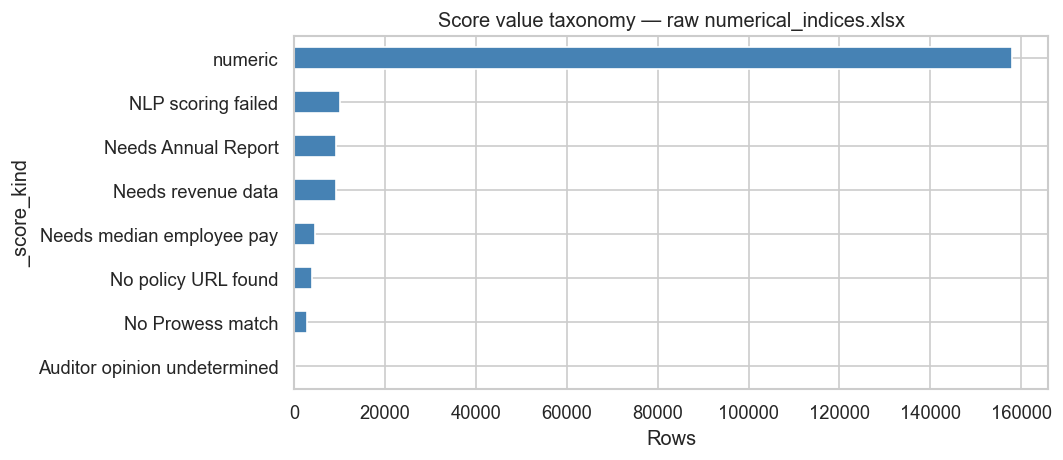

In [4]:
def score_kind(x):
    try:
        float(x)
        return 'numeric'
    except (TypeError, ValueError):
        return str(x).strip()

raw['_score_kind'] = raw['Score'].apply(score_kind)
kind_counts = raw['_score_kind'].value_counts()
print(kind_counts)
print(f"\nNumeric scores: {kind_counts.get('numeric',0):,} ({kind_counts.get('numeric',0)/len(raw):.1%})")

fig, ax = plt.subplots(figsize=(9, 4))
kind_counts.plot(kind='barh', ax=ax, color='steelblue')
ax.set_title('Score value taxonomy — raw numerical_indices.xlsx')
ax.set_xlabel('Rows'); ax.invert_yaxis()
plt.tight_layout(); plt.show()

### 1.2 — ID-prefix / Category consistency

Every metric ID is prefixed by its expected category (`A*`→AINDEX, `B*`→BINDEX, etc.). Flags any metric filed under a category its own ID doesn't match.

This check originally caught O7 ("Concentrated ownership type") filed under TRINDEX
instead of OINDEX — now corrected at load time above (see the recode cell right after the
imports), matching `cg_scores_formulas.xlsx`'s own classification and applied identically
in `06_index_calculation.ipynb`. This cell is kept as a standing regression test and
should report all-consistent going forward.</cell id="ef5eb57e">

In [5]:
meta = raw[['ID', 'Metric', 'Category']].drop_duplicates()
meta['id_prefix'] = meta['ID'].str.extract(r'^([A-Za-z]+)')
prefix_to_cat = {'A': 'AINDEX', 'B': 'BINDEX', 'D': 'DINDEX', 'O': 'OINDEX', 'TR': 'TRINDEX'}
meta['expected_category'] = meta['id_prefix'].map(prefix_to_cat)
mismatches = meta[meta['expected_category'] != meta['Category']]
print(mismatches.to_string(index=False) if len(mismatches) else '(all consistent)')

(all consistent)


### 1.3 — Missingness by metric, and a cross-check against `DROP_IDS`

`06_index_calculation.ipynb` explicitly excludes 6 metric IDs for data-quality reasons. This checks whether any *other* metric is just as broken (100% or near-100% non-numeric) but isn't excluded — those rows still enter `groupby(...).sum()` as silent no-ops (NaN is skipped), so nothing crashes, but the metric is dead weight nobody documented.

In [6]:
placeholder_rate = (raw.assign(is_placeholder=raw['_score_kind'] != 'numeric')
                       .groupby(['Category', 'ID', 'Metric'])['is_placeholder']
                       .mean().mul(100).round(1)
                       .reset_index(name='pct_non_numeric')
                       .sort_values('pct_non_numeric', ascending=False))
print(placeholder_rate.head(10).to_string(index=False))

fully_dead = placeholder_rate[placeholder_rate['pct_non_numeric'] >= 99.5]
undocumented_dead = fully_dead[~fully_dead['ID'].isin(DROP_IDS)]
print(f"\nMetrics that are ≥99.5% non-numeric: {list(fully_dead['ID'])}")
print(f"Of those, NOT already excluded via DROP_IDS: {list(undocumented_dead['ID'])}")
if len(undocumented_dead):
    print(undocumented_dead.to_string(index=False))

Category  ID                                    Metric  pct_non_numeric
  BINDEX  B7   Former CEOs should not be board members            100.0
  OINDEX  O4                           ID Shareholding            100.0
 TRINDEX TR4    CEO pay to median employee's pay ratio            100.0
 TRINDEX TR2        CEO remuneration as a % of revenue            100.0
 TRINDEX TR1   Director remuneration as a % of revenue            100.0
  DINDEX  D4                     Quality of RPT policy             67.4
  DINDEX  D2           Quality of whistleblower policy             65.8
  DINDEX  D3 Quality of policy against insider trading             62.8
  DINDEX  D5        Quality of Board Evaluation Policy             61.0
  AINDEX  A8                         Auditor's Opinion             48.1

Metrics that are ≥99.5% non-numeric: ['B7', 'O4', 'TR4', 'TR2', 'TR1']
Of those, NOT already excluded via DROP_IDS: []


### 1.4 — Missingness by company (top 10)

In [7]:
comp_placeholder = (raw.assign(is_placeholder=raw['_score_kind'] != 'numeric')
                       .groupby('company_name')['is_placeholder']
                       .mean().mul(100).round(1)
                       .sort_values(ascending=False))
print(comp_placeholder.head(10))

company_name
ICICI Securities Limited          48.8
UNIONBANK                         48.8
KANSAI NEROLAC PAINTS LIMITED     48.8
KANSAIN NEROLAC PAINTS LIMITED    48.8
Kansai Nerolac Paints Limited     48.8
Affle (India) Limited             48.8
ICICI SECURITIES LIMITED          48.8
HATSUN AGRO PRODUCT LIMITED       48.8
AFFLE (INDIA) LIMITED             48.8
GE T&D India Ltd                  48.8
Name: is_placeholder, dtype: float64


### 1.5 — Coverage over time

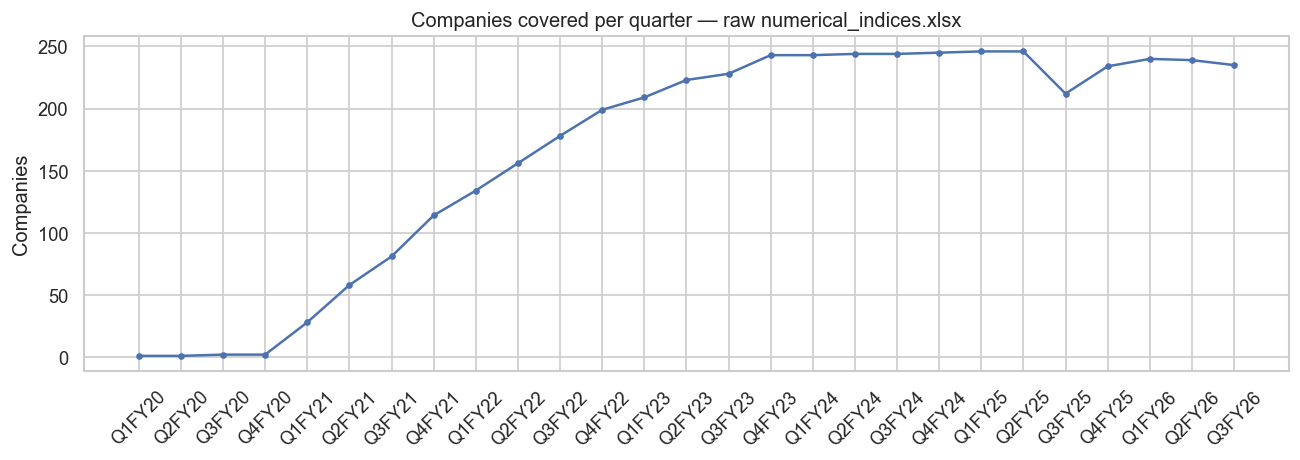

         rows  companies
Q_FY                    
Q1FY20     43          1
Q2FY20     43          1
Q3FY20     86          2
Q4FY20     86          2
Q1FY21   1247         28
Q2FY21   2580         58
Q3FY21   3526         81
Q4FY21   4945        114
Q1FY22   5848        134
Q2FY22   6794        156
Q3FY22   7783        178
Q4FY22   8815        199
Q1FY23   9245        209
Q2FY23   9847        223
Q3FY23   9976        228
Q4FY23  10621        243
Q1FY24  10621        243
Q2FY24  10621        244
Q3FY24  10621        244
Q4FY24  10621        245
Q1FY25  10750        246
Q2FY25  11739        246
Q3FY25   9202        212
Q4FY25  10105        234
Q1FY26  10449        240
Q2FY26  10664        239
Q3FY26  10922        235


In [8]:
cov = raw.groupby('Q_FY').agg(rows=('ID', 'size'), companies=('symbol', 'nunique'))
cov = cov.reindex(sorted(cov.index, key=q_sort_key))

fig, ax = plt.subplots(figsize=(11, 4))
ax.plot(cov.index, cov['companies'], marker='o', ms=3)
ax.set_title('Companies covered per quarter — raw numerical_indices.xlsx')
ax.set_ylabel('Companies'); ax.tick_params(axis='x', rotation=45)
plt.tight_layout(); plt.show()
print(cov.to_string())

### 1.6 — Duplicate rows

Same (company, period, metric) reported more than once. Checks whether duplicates just repeat the same score (harmless) or genuinely conflict (a real data-integrity issue, since both rows enter the same `groupby().sum()` and silently blend two different scores).

In [9]:
dupe_mask = raw.duplicated(subset=['symbol', 'period_end', 'ID'], keep=False)
dupes = raw[dupe_mask]
dupe_groups = dupes.groupby(['symbol', 'period_end', 'ID'])['Score'].nunique()
n_exact = (dupe_groups == 1).sum()
n_conflict = (dupe_groups > 1).sum()

print(f"Duplicate (symbol, period_end, ID) rows : {dupe_mask.sum():,} / {len(raw):,}")
print(f"Duplicate groups                        : {len(dupe_groups):,}")
print(f"  Exact repeats (same score)            : {n_exact:,}")
print(f"  CONFLICTING (different scores)        : {n_conflict:,}")

if n_conflict:
    conflict_keys = dupe_groups[dupe_groups > 1].index[:5]
    print('\nSample conflicts:')
    for sym, pend, mid in conflict_keys:
        sub = dupes[(dupes['symbol'] == sym) & (dupes['period_end'] == pend) & (dupes['ID'] == mid)]
        print(sub[['symbol', 'period_end', 'ID', 'Score', 'file']].to_string(index=False))
        print()

Duplicate (symbol, period_end, ID) rows : 7,396 / 197,800
Duplicate groups                        : 2,881
  Exact repeats (same score)            : 2,736
  CONFLICTING (different scores)        : 97

Sample conflicts:
 symbol period_end ID   Score                               file
3MINDIA 2022-03-31 B6  0.7454 523395_523395_2042022105949_CG.xml
3MINDIA 2022-03-31 B6  0.9129   523395_523395_95202211393_CG.xml

symbol period_end  ID Score                                 file
   ACC 2024-06-30 B12     0 500410_CG_500410_090120250521_CG.xml
   ACC 2024-06-30 B12     1    500410_500410_187202415428_CG.xml

symbol period_end ID Score                                 file
   ACC 2024-06-30 B9   0.5 500410_CG_500410_090120250521_CG.xml
   ACC 2024-06-30 B9     1    500410_500410_187202415428_CG.xml

    symbol period_end ID   Score                                   file
ADANIPOWER 2024-09-30 A4  0.7352 533096_CG_533096_26102024184347_CG.xml
ADANIPOWER 2024-09-30 A4  0.8342      533096_533096_1

### 1.7 — Processed output sanity (`cg_scores.csv`)

In [10]:
print(f"Avg_Score range : [{scores['Avg_Score'].min():.4f}, {scores['Avg_Score'].max():.4f}]")
oor = ((scores['Avg_Score'] < 0) | (scores['Avg_Score'] > 1)).sum()
print(f"Out of [0,1]    : {oor}")
print(f"Nulls           : {scores['Avg_Score'].isna().sum()}")

coverage = scores.groupby(['BSE Code', 'Q_FY'])['Category'].nunique().value_counts().sort_index()
print(f"\nCategories present per (firm, quarter) — expect 6:")
print(coverage)

Avg_Score range : [0.0000, 0.9995]
Out of [0,1]    : 0
Nulls           : 0

Categories present per (firm, quarter) — expect 6:
Category
1     338
6    4197
Name: count, dtype: int64


---
## Section 2 — Internal Consistency (Cronbach's Alpha)

Reliability is computed on **complete cases only** (a firm-period row must have every
item in the category present) rather than the imputed/weighted production data —
imputing first would artificially inflate any reliability estimate. `n_obs_complete`
tells you how much data that discipline actually leaves; a category can look unreliable
simply because complete cases are scarce.

In [11]:
def cronbach_alpha(items_df):
    """items_df: rows=observations, columns=items. Complete-case only."""
    df = items_df.dropna(axis=0, how='any')
    n, k = df.shape
    if k < 2 or n < 3:
        return np.nan, k, n
    item_var_sum = df.var(axis=0, ddof=1).sum()
    total_var = df.sum(axis=1).var(ddof=1)
    alpha = (k / (k - 1)) * (1 - item_var_sum / total_var)
    return alpha, k, n

def item_total_correlations(items_df):
    """Corrected item-total correlation: each item vs the sum of all others."""
    df = items_df.dropna(axis=0, how='any')
    total = df.sum(axis=1)
    return pd.Series({c: df[c].corr(total - df[c]) for c in df.columns}).sort_values()

alpha_results = []
item_total_tables = {}

for cat in ['AINDEX', 'BINDEX', 'DINDEX', 'OINDEX', 'TRINDEX']:
    sub = raw[raw['Category'] == cat]
    wide = sub.pivot_table(index=['symbol', 'period_end'], columns='ID', values='_numeric_score')
    alpha, k, n = cronbach_alpha(wide)
    alpha_results.append({'Category': cat, 'n_items': k, 'n_obs_complete': n, 'cronbach_alpha': alpha})
    item_total_tables[cat] = item_total_correlations(wide)

# CINDEX: BSE_code is already present, no symbol join needed; Score is already numeric
cw = cindex_raw.pivot_table(index=['BSE_code', 'period_end'], columns='ID', values='Score')
a, k, n = cronbach_alpha(cw)
alpha_results.append({'Category': 'CINDEX', 'n_items': k, 'n_obs_complete': n, 'cronbach_alpha': a})
item_total_tables['CINDEX'] = item_total_correlations(cw)

alpha_df = pd.DataFrame(alpha_results)

def rate(a):
    if pd.isna(a): return 'n/a'
    if a >= 0.8: return 'good'
    if a >= 0.7: return 'acceptable'
    if a >= 0.5: return 'weak'
    return 'poor'

alpha_df['rating'] = alpha_df['cronbach_alpha'].apply(rate)
print(alpha_df.to_string(index=False))
print('\nNote: n_items is often < the category\'s full metric count — pivot_table drops any')
print('metric that is 100% non-numeric (see Section 1.3), since it has nothing to pivot.')

Category  n_items  n_obs_complete  cronbach_alpha rating
  AINDEX        9            1607       -0.188584   poor
  BINDEX       14            2851        0.312498   poor
  DINDEX        5            1304        0.677206   weak
  OINDEX        6            3874       -0.083782   poor
 TRINDEX        4            3341        0.077180   poor
  CINDEX       10            4535        0.654459   weak

Note: n_items is often < the category's full metric count — pivot_table drops any
metric that is 100% non-numeric (see Section 1.3), since it has nothing to pivot.


In [12]:
for cat, tbl in item_total_tables.items():
    weak = tbl[tbl < 0.2].index.tolist()
    print(f'--- {cat} — item-total correlations ---')
    print(tbl.round(3).to_string())
    overlap = sorted(set(weak) & set(DROP_IDS))
    print(f'Weak items (r<0.2): {weak}  |  already excluded via DROP_IDS: {overlap}\n')

--- AINDEX — item-total correlations ---
A6   -0.250
A7   -0.228
A1   -0.128
A9   -0.104
A2   -0.015
A5    0.023
A4    0.082
A3    0.212
A8      NaN
Weak items (r<0.2): ['A6', 'A7', 'A1', 'A9', 'A2', 'A5', 'A4']  |  already excluded via DROP_IDS: []

--- BINDEX — item-total correlations ---
B4    -0.095
B2    -0.094
B8    -0.057
B1    -0.035
B5    -0.024
B6     0.008
B14    0.032
B15    0.051
B3     0.184
B13    0.194
B10    0.237
B11    0.294
B12    0.339
B9     0.402
Weak items (r<0.2): ['B4', 'B2', 'B8', 'B1', 'B5', 'B6', 'B14', 'B15', 'B3', 'B13']  |  already excluded via DROP_IDS: ['B13', 'B14']

--- DINDEX — item-total correlations ---
D1    0.031
D5    0.549
D2    0.584
D3    0.620
D4    0.668
Weak items (r<0.2): ['D1']  |  already excluded via DROP_IDS: []

--- OINDEX — item-total correlations ---
O7   -0.459
O3    0.012
O1    0.030
O5    0.195
O2    0.263
O6    0.387
Weak items (r<0.2): ['O7', 'O3', 'O1', 'O5']  |  already excluded via DROP_IDS: []

--- TRINDEX — item-total co

### 2.1 — Alpha-if-item-deleted

For each item, recompute Cronbach's α on the same complete-case item pool with just that
one item removed. An item whose removal *increases* α is dragging down the sub-index's
internal consistency relative to its peers — worth flagging even though (per the note
above) a low baseline α here reflects the SEBI-checklist construction, not necessarily a
broken item. Flagged as material at Δα > 0.05.

In [13]:
MATERIAL_ALPHA_DELTA = 0.05

def alpha_if_deleted(items_df):
    """Cronbach's alpha of the item pool with each single item removed, complete-case."""
    df = items_df.dropna(axis=0, how='any')
    out = {}
    for col in df.columns:
        remaining = df.drop(columns=[col])
        if remaining.shape[1] < 2:
            out[col] = np.nan
            continue
        a, _, _ = cronbach_alpha(remaining)
        out[col] = a
    return pd.Series(out)

alpha_lookup = alpha_df.set_index('Category')['cronbach_alpha'].to_dict()
alpha_deleted_rows = []

for cat, item_totals in item_total_tables.items():
    if cat == 'CINDEX':
        wide_items = cindex_raw.pivot_table(index=['BSE_code', 'period_end'], columns='ID', values='Score')
    else:
        wide_items = raw[raw['Category'] == cat].pivot_table(
            index=['symbol', 'period_end'], columns='ID', values='_numeric_score')
    ad = alpha_if_deleted(wide_items)
    base_alpha = alpha_lookup[cat]
    for item_id, a_wo in ad.items():
        alpha_deleted_rows.append({
            'Category': cat, 'ID': item_id,
            'alpha_full': base_alpha, 'alpha_if_deleted': a_wo,
            'delta': a_wo - base_alpha if pd.notna(a_wo) else np.nan,
        })

alpha_deleted_df = pd.DataFrame(alpha_deleted_rows).sort_values(['Category', 'delta'], ascending=[True, False])
print(alpha_deleted_df.round(4).to_string(index=False))

material = alpha_deleted_df[alpha_deleted_df['delta'] > MATERIAL_ALPHA_DELTA]
print(f"\nItems whose removal improves their sub-index's alpha by > {MATERIAL_ALPHA_DELTA}:")
print(material.round(4).to_string(index=False) if len(material) else '(none)')

Category  ID  alpha_full  alpha_if_deleted   delta
  AINDEX  A6     -0.1886            0.0607  0.2493
  AINDEX  A7     -0.1886           -0.0360  0.1526
  AINDEX  A1     -0.1886           -0.0912  0.0974
  AINDEX  A9     -0.1886           -0.1016  0.0869
  AINDEX  A8     -0.1886           -0.1916 -0.0030
  AINDEX  A2     -0.1886           -0.1985 -0.0099
  AINDEX  A5     -0.1886           -0.2267 -0.0381
  AINDEX  A4     -0.1886           -0.4021 -0.2135
  AINDEX  A3     -0.1886           -0.4546 -0.2660
  BINDEX  B2      0.3125            0.3860  0.0735
  BINDEX  B4      0.3125            0.3601  0.0476
  BINDEX  B1      0.3125            0.3394  0.0269
  BINDEX  B8      0.3125            0.3320  0.0195
  BINDEX B14      0.3125            0.3269  0.0144
  BINDEX B15      0.3125            0.3226  0.0101
  BINDEX  B5      0.3125            0.3195  0.0070
  BINDEX  B6      0.3125            0.3173  0.0048
  BINDEX B13      0.3125            0.2605 -0.0520
  BINDEX  B3      0.3125       

---
## Section 3 — Sub-index Relationships

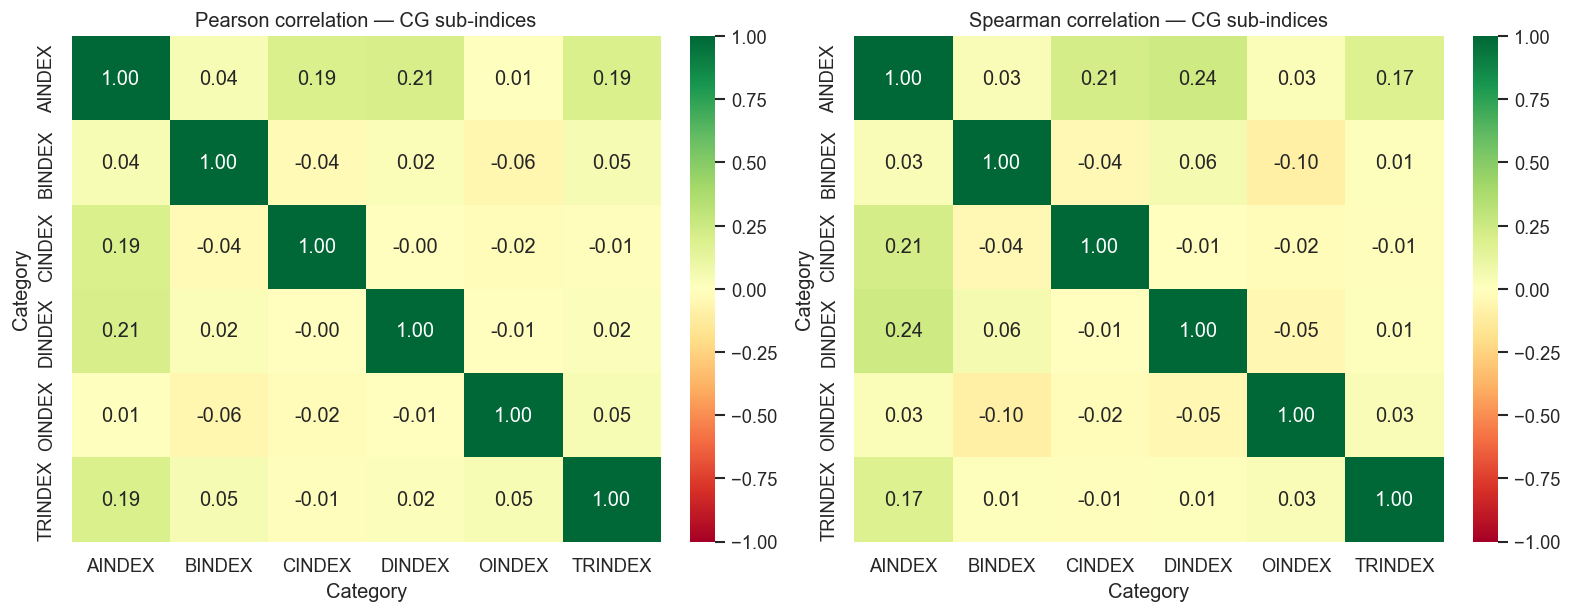

In [14]:
wide_scores = scores.pivot_table(index=['BSE Code', 'Q_FY'], columns='Category', values='Avg_Score').reset_index()
cats = ['AINDEX', 'BINDEX', 'CINDEX', 'DINDEX', 'OINDEX', 'TRINDEX']
cats = [c for c in cats if c in wide_scores.columns]

pearson_corr = wide_scores[cats].corr(method='pearson')
spearman_corr = wide_scores[cats].corr(method='spearman')

fig, axes = plt.subplots(1, 2, figsize=(13, 5), constrained_layout=True)
sns.heatmap(pearson_corr, annot=True, fmt='.2f', cmap='RdYlGn', center=0, ax=axes[0], vmin=-1, vmax=1)
axes[0].set_title('Pearson correlation — CG sub-indices')
sns.heatmap(spearman_corr, annot=True, fmt='.2f', cmap='RdYlGn', center=0, ax=axes[1], vmin=-1, vmax=1)
axes[1].set_title('Spearman correlation — CG sub-indices')
plt.show()

In [15]:
print('Pearson correlation matrix — CG sub-indices:')
print(pearson_corr.round(3).to_string())
print('\nSpearman correlation matrix — CG sub-indices:')
print(spearman_corr.round(3).to_string())

Pearson correlation matrix — CG sub-indices:
Category  AINDEX  BINDEX  CINDEX  DINDEX  OINDEX  TRINDEX
Category                                                 
AINDEX     1.000   0.042   0.192   0.209   0.007    0.194
BINDEX     0.042   1.000  -0.036   0.024  -0.057    0.053
CINDEX     0.192  -0.036   1.000  -0.002  -0.022   -0.015
DINDEX     0.209   0.024  -0.002   1.000  -0.007    0.019
OINDEX     0.007  -0.057  -0.022  -0.007   1.000    0.045
TRINDEX    0.194   0.053  -0.015   0.019   0.045    1.000

Spearman correlation matrix — CG sub-indices:
Category  AINDEX  BINDEX  CINDEX  DINDEX  OINDEX  TRINDEX
Category                                                 
AINDEX     1.000   0.032   0.215   0.244   0.027    0.173
BINDEX     0.032   1.000  -0.042   0.062  -0.098    0.015
CINDEX     0.215  -0.042   1.000  -0.007  -0.021   -0.010
DINDEX     0.244   0.062  -0.007   1.000  -0.047    0.015
OINDEX     0.027  -0.098  -0.021  -0.047   1.000    0.035
TRINDEX    0.173   0.015  -0.010   0.0

### 3.1 — Multicollinearity (VIF)

If the sub-indices were largely redundant, using several as simultaneous regressors (as `08_regression.ipynb`'s joint model does) would be unstable. VIF > 5 is a concern, > 10 severe.

In [16]:
vif_df = wide_scores[cats].dropna()
X = sm.add_constant(vif_df)
vif_rows = [{'Category': c, 'VIF': variance_inflation_factor(X.values, i + 1)} for i, c in enumerate(cats)]
vif_table = pd.DataFrame(vif_rows).sort_values('VIF', ascending=False)
print(f'N complete-case rows: {len(vif_df):,}')
print(vif_table.to_string(index=False))

N complete-case rows: 4,197
Category      VIF
  AINDEX 1.135460
  DINDEX 1.048605
 TRINDEX 1.047279
  CINDEX 1.045957
  BINDEX 1.009618
  OINDEX 1.006275


### 3.2 — Distribution shape & normality

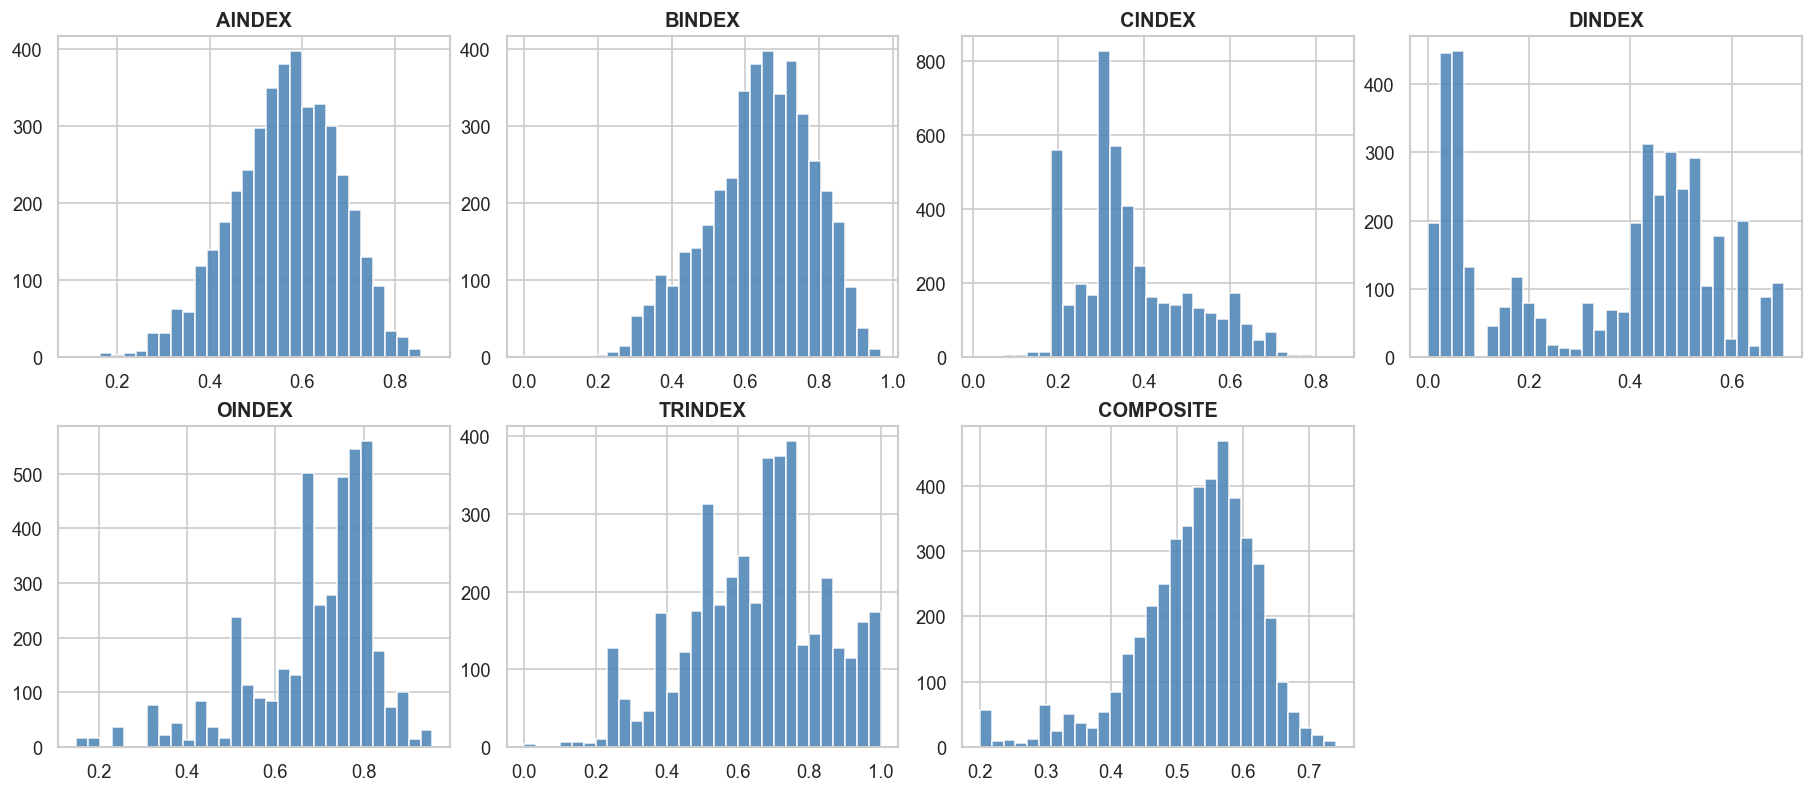

 Category    N    skew  kurtosis  JB_p  normal_at_5%
   AINDEX 4197 -0.2864    2.8920   0.0         False
   BINDEX 4197 -0.4292    2.7696   0.0         False
   CINDEX 4535  0.7326    2.8961   0.0         False
   DINDEX 4197 -0.2162    1.5596   0.0         False
   OINDEX 4197 -1.2571    4.5736   0.0         False
  TRINDEX 4197 -0.2956    2.6191   0.0         False
COMPOSITE 4535 -1.0414    4.6432   0.0         False


In [17]:
wide_scores['COMPOSITE'] = wide_scores[cats].mean(axis=1)
dist_cols = cats + ['COMPOSITE']

fig, axes = plt.subplots(2, 4, figsize=(15, 6.5), constrained_layout=True)
for ax, col in zip(axes.flat, dist_cols):
    vals = wide_scores[col].dropna()
    ax.hist(vals, bins=30, color='steelblue', alpha=0.85)
    ax.set_title(col, fontweight='bold')
for ax in axes.flat[len(dist_cols):]:
    ax.axis('off')
plt.show()

norm_rows = []
for col in dist_cols:
    vals = wide_scores[col].dropna().values
    jb_stat, jb_p, skew, kurt = jarque_bera(vals)
    norm_rows.append({'Category': col, 'N': len(vals), 'skew': skew, 'kurtosis': kurt,
                       'JB_p': jb_p, 'normal_at_5%': jb_p > 0.05})
print(pd.DataFrame(norm_rows).round(4).to_string(index=False))

### 3.3 — PCA factor structure (diagnostic only)

Standardises each of the six sub-indices cross-sectionally within its own Q_FY, then
extracts the full principal-component decomposition (not just PC1) to check whether a
single dominant "governance quality" factor exists. **This is diagnostic only — no PCA
score is constructed as a variable anywhere in this pipeline** (see `06`'s header note).
A near-flat scree (no PC explaining a clear majority of variance) plus mixed-sign loadings
would indicate the six sub-indices are closer to independent measures than to noisy
realisations of one latent construct.

Complete-case (all 6 sub-indices present) firm-quarters: 4,197 / 4,535

Scree — variance explained by each component:
Component  Variance_explained  Cumulative
      PC1              0.2201      0.2201
      PC2              0.1845      0.4046
      PC3              0.1741      0.5787
      PC4              0.1574      0.7361
      PC5              0.1461      0.8821
      PC6              0.1179      1.0000

PC1 loadings (sign arbitrary):
AINDEX     0.675
DINDEX     0.527
TRINDEX    0.478
BINDEX     0.177
OINDEX     0.058
CINDEX    -0.056


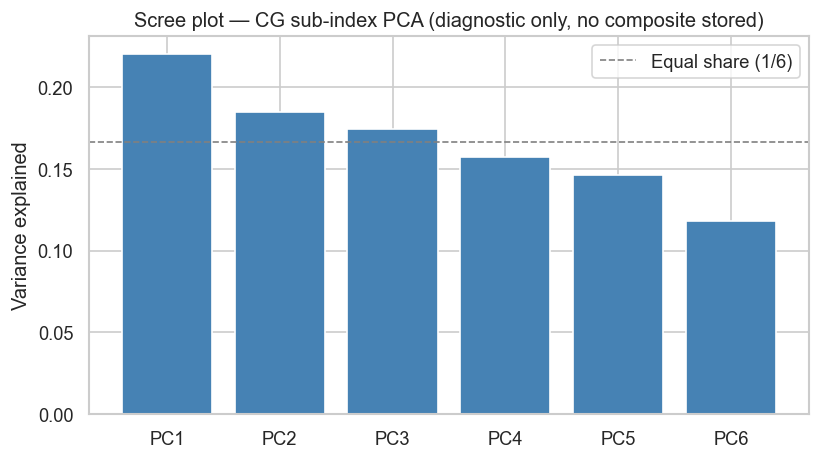

In [18]:
from sklearn.decomposition import PCA

wide_z = wide_scores[['BSE Code', 'Q_FY'] + cats].copy()
wide_z[cats] = wide_z.groupby('Q_FY')[cats].transform(lambda s: (s - s.mean()) / s.std(ddof=0))
wide_z[cats] = wide_z[cats].replace([np.inf, -np.inf], np.nan)
complete = wide_z.dropna(subset=cats)
print(f'Complete-case (all 6 sub-indices present) firm-quarters: {len(complete):,} / {len(wide_z):,}')

pca_full = PCA(n_components=len(cats))
pca_full.fit(complete[cats].values)

scree = pd.DataFrame({
    'Component': [f'PC{i+1}' for i in range(len(cats))],
    'Variance_explained': pca_full.explained_variance_ratio_,
    'Cumulative': np.cumsum(pca_full.explained_variance_ratio_),
})
print('\nScree — variance explained by each component:')
print(scree.round(4).to_string(index=False))

loadings_pc1 = pd.Series(pca_full.components_[0], index=cats).sort_values(ascending=False)
print('\nPC1 loadings (sign arbitrary):')
print(loadings_pc1.round(3).to_string())

fig, ax = plt.subplots(figsize=(7, 4))
ax.bar(scree['Component'], scree['Variance_explained'], color='steelblue')
ax.axhline(1 / len(cats), color='grey', ls='--', lw=1, label=f'Equal share (1/{len(cats)})')
ax.set_title('Scree plot — CG sub-index PCA (diagnostic only, no composite stored)')
ax.set_ylabel('Variance explained')
ax.legend()
plt.tight_layout(); plt.show()

**Interpretation.** PC1 explains only ~21% of total variance — barely above the 16.7%
floor that six mutually uncorrelated variables would produce by construction — and its
loadings are mixed-sign (AINDEX, TRINDEX, BINDEX, DINDEX, and OINDEX positive; CINDEX
negative). Combined with the near-1.0 VIFs in §3.1 and the weak-to-poor Cronbach's alphas
in §2, this is consistent evidence that **no dominant latent "governance quality" factor
exists across these six measures**. They should be read as six substantively distinct
regulatory/disclosure constructs — audit-committee structure, board conduct, disclosure
quality, ownership structure, transparency/remuneration, and NLP-scored report
content — not as noisy realisations of one underlying trait. The equal-weight mean
composite (`Avg_Score` in `cg_scores.csv`) is reported downstream as a **summary
convenience for headline tables**, not as a factor-analytically justified index; the
sub-index-level results are the primary evidence, and PC1 is not carried forward as a
variable anywhere in this pipeline.

---
## Section 4 — Robustness & Stability

### 4.1 — Temporal persistence

Governance quality should be a slow-moving firm characteristic — a firm's score this quarter should correlate strongly with its score last available quarter. Low persistence would suggest the scoring process is noisy rather than measuring something real. ("Previous quarter" here means the previous quarter *with data* for that firm, not necessarily a strictly adjacent calendar quarter if there are gaps.)

In [19]:
persist_rows = []
for cat in cats:
    sub = scores[scores['Category'] == cat].copy()
    sub['_qi'] = sub['Q_FY'].map(q_sort_key)
    sub = sub.sort_values(['BSE Code', '_qi'])
    sub['lag_score'] = sub.groupby('BSE Code')['Avg_Score'].shift(1)
    consecutive = sub.dropna(subset=['lag_score'])
    r = consecutive['Avg_Score'].corr(consecutive['lag_score'])
    persist_rows.append({'Category': cat, 'N_pairs': len(consecutive), 'lag1_corr': r})

persist_df = pd.DataFrame(persist_rows)
print(persist_df.round(3).to_string(index=False))
print('\nHigh lag-1 correlation (>0.5) is expected for a slow-moving construct.')

Category  N_pairs  lag1_corr
  AINDEX     3966      0.850
  BINDEX     3966      0.890
  CINDEX     4288      0.805
  DINDEX     3966      1.000
  OINDEX     3966      1.000
 TRINDEX     3966      0.848

High lag-1 correlation (>0.5) is expected for a slow-moving construct.


### 4.2 — Hard-break scan

Generalizes the discovery behind dropping `B14` ("all zeros from Q3FY25 onward"): flags any metric whose score variance collapses to near-zero in its last 2 reported quarters after having real variance before that — the signature of a scraper/scoring failure rather than genuine convergence.

In [20]:
metric_quarter_stats = (raw.groupby(['ID', 'Q_FY'])['_numeric_score']
                            .agg(['mean', 'std', 'count']).reset_index())

flagged = []
for mid, g in metric_quarter_stats.groupby('ID'):
    g = g.sort_values('Q_FY', key=lambda s: s.map(q_sort_key))
    if len(g) < 4:
        continue
    tail = g.tail(2)
    head = g.iloc[:-2]
    if tail['std'].max() < 0.01 and head['std'].max() > 0.05:
        flagged.append({'ID': mid, 'tail_std_max': tail['std'].max(),
                         'head_std_max': head['std'].max(),
                         'tail_quarters': list(tail['Q_FY'])})

flagged_df = pd.DataFrame(flagged)
print(f'Metrics with a hard break to near-zero variance: {len(flagged_df)}')
print(flagged_df.to_string(index=False) if len(flagged_df) else '(none found)')
if len(flagged_df):
    already_excluded = [f for f in flagged_df['ID'] if f in DROP_IDS]
    print(f'\nAlready excluded via DROP_IDS: {already_excluded}')

Metrics with a hard break to near-zero variance: 1
 ID  tail_std_max  head_std_max    tail_quarters
B14           0.0      0.269689 [Q2FY26, Q3FY26]

Already excluded via DROP_IDS: ['B14']


### 4.3 — Weighting & drop-ID sensitivity

Rebuilds the composite two different ways directly from the raw item pool (not from `06`'s in-memory state) and checks how much the choice actually matters. Uses a plain symbol→BSE Code join (no manual overrides), so coverage is a little lower than production — fine for a relative-ranking check. CINDEX is excluded here since production already averages it unweighted.

Matched to a BSE Code (no manual overrides): 187,609 / 197,800 (94.8%)


SEBI-weighted vs. equal-weighted composite:
Category    N  spearman_r_weighted_vs_equal
  AINDEX 4299                         1.000
  BINDEX 4299                         0.870
  DINDEX 4145                         0.976
  OINDEX 4107                         1.000
 TRINDEX 4299                         1.000



Excluding vs. including the DROP_IDS metrics (production vs. no exclusions):
Category    N  spearman_r_excl_vs_incl_dropped_ids
  AINDEX 4299                                1.000
  BINDEX 4299                                0.934
  DINDEX 4145                                1.000
  OINDEX 4107                                1.000
 TRINDEX 4299                                1.000


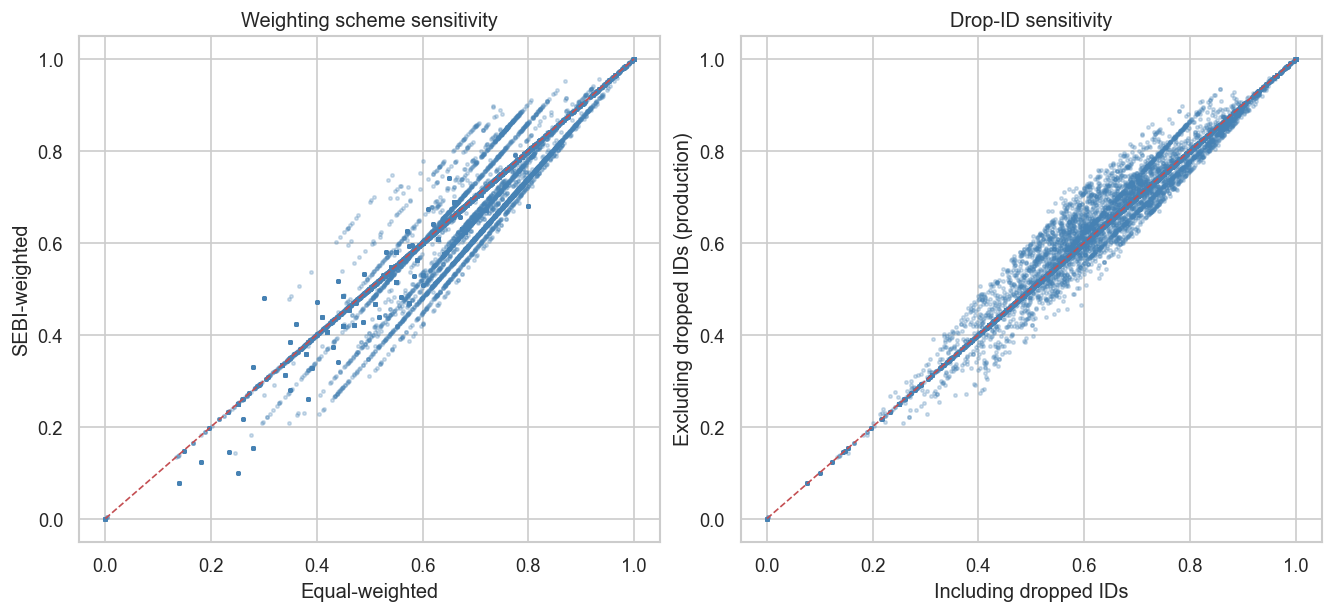

In [21]:
matched['_key'] = matched['NSE Symbol'].str.strip().str.upper()
raw['_key'] = raw['symbol'].str.strip().str.upper()
bse_map = matched.set_index('_key')['BSE Code'].to_dict()
raw['BSE Code'] = raw['_key'].map(bse_map)

matched_n = raw['BSE Code'].notna().sum()
print(f'Matched to a BSE Code (no manual overrides): {matched_n:,} / {len(raw):,} ({matched_n/len(raw):.1%})')

sebi_map = formulas.dropna(subset=['ID']).set_index('ID')['SEBI'].to_dict()
weight_map = {'Mandates': 1, 'Recommends': 2, 'Over the Mandate': 4}
raw['Weight'] = raw['ID'].map(sebi_map).map(weight_map).fillna(4)

item_pool = raw.dropna(subset=['BSE Code', '_numeric_score']).copy()
item_pool['BSE Code'] = item_pool['BSE Code'].astype(int)

def build_composite(df, weighted):
    g = df.groupby(['BSE Code', 'Q_FY', 'Category'])
    if weighted:
        return (g.apply(lambda x: (x['_numeric_score'] * x['Weight']).sum() / x['Weight'].sum())
                  .reset_index(name='score'))
    return g['_numeric_score'].mean().reset_index(name='score')

WEIGHTED_CATS = ['AINDEX', 'BINDEX', 'DINDEX', 'OINDEX', 'TRINDEX']
no_drop   = item_pool
with_drop = item_pool[~item_pool['ID'].isin(DROP_IDS)]

weighted_prod = build_composite(with_drop, weighted=True).rename(columns={'score': 'weighted'})
equal_prod    = build_composite(with_drop, weighted=False).rename(columns={'score': 'equal'})
weight_cmp = weighted_prod.merge(equal_prod, on=['BSE Code', 'Q_FY', 'Category'])

weight_rows = []
for cat in WEIGHTED_CATS:
    sub = weight_cmp[weight_cmp['Category'] == cat]
    if len(sub) < 10:
        continue
    r = sub['weighted'].corr(sub['equal'], method='spearman')
    weight_rows.append({'Category': cat, 'N': len(sub), 'spearman_r_weighted_vs_equal': r})
weight_df = pd.DataFrame(weight_rows)
print('SEBI-weighted vs. equal-weighted composite:')
print(weight_df.round(3).to_string(index=False))

weighted_alldrops = build_composite(with_drop, weighted=True).rename(columns={'score': 'excl_dropped'})
weighted_nodrops  = build_composite(no_drop,   weighted=True).rename(columns={'score': 'incl_dropped'})
drop_cmp = weighted_alldrops.merge(weighted_nodrops, on=['BSE Code', 'Q_FY', 'Category'])

drop_rows = []
for cat in WEIGHTED_CATS:
    sub = drop_cmp[drop_cmp['Category'] == cat]
    if len(sub) < 10:
        continue
    r = sub['excl_dropped'].corr(sub['incl_dropped'], method='spearman')
    drop_rows.append({'Category': cat, 'N': len(sub), 'spearman_r_excl_vs_incl_dropped_ids': r})
drop_df = pd.DataFrame(drop_rows)
print('\nExcluding vs. including the DROP_IDS metrics (production vs. no exclusions):')
print(drop_df.round(3).to_string(index=False))

fig, axes = plt.subplots(1, 2, figsize=(11, 5), constrained_layout=True)
axes[0].scatter(weight_cmp['equal'], weight_cmp['weighted'], s=4, alpha=0.25, color='steelblue')
axes[0].plot([0, 1], [0, 1], 'r--', lw=1)
axes[0].set(xlabel='Equal-weighted', ylabel='SEBI-weighted', title='Weighting scheme sensitivity')
axes[1].scatter(drop_cmp['incl_dropped'], drop_cmp['excl_dropped'], s=4, alpha=0.25, color='steelblue')
axes[1].plot([0, 1], [0, 1], 'r--', lw=1)
axes[1].set(xlabel='Including dropped IDs', ylabel='Excluding dropped IDs (production)', title='Drop-ID sensitivity')
plt.show()

---
## Section 5 — External Benchmark Comparison

Checks the CG composite against an off-the-shelf, independently-constructed governance
classification (e.g. NSE Prime market-segment membership) as an external validity check —
if the composite tracks a well-known external tier, that's evidence it's measuring
something real rather than an artifact of this project's own scoring rules.

In [22]:
# Search the project's raw/processed universe files for anything resembling an
# external governance-tier classification (e.g. NSE Prime segment membership).
seed = pd.read_excel(RAW / 'matched_companies_seed.xlsx')

def find_candidate_cols(df, keywords=('prime', 'segment', 'tier', 'grade', 'rating')):
    return [c for c in df.columns if any(k in c.lower() for k in keywords)]

print(f"matched_companies_seed.xlsx columns : {list(seed.columns)}")
print(f"  matching prime/segment/tier/grade/rating : {find_candidate_cols(seed) or '(none)'}")

print(f"\nmatched_companies.xlsx columns      : {list(matched.columns)}")
print(f"  matching prime/segment/tier/grade/rating : {find_candidate_cols(matched) or '(none)'}")

print(f"\ntop_500_companies.xlsx columns      : "
      f"{list(pd.read_excel(RAW / 'top_500_companies.xlsx').columns)}")

benchmark_available = False
print(f"\nExternal governance-tier benchmark available in data/raw or data/processed: {benchmark_available}")

matched_companies_seed.xlsx columns : ['BSE Name', 'BSE Code', 'Prowess Name', 'NSE Symbol']
  matching prime/segment/tier/grade/rating : (none)

matched_companies.xlsx columns      : ['BSE Code', 'NSE Symbol', '_key']
  matching prime/segment/tier/grade/rating : (none)

top_500_companies.xlsx columns      : ['Sr No', 'Scrip Code', 'Company Name', 'Average market capitalisation from July  01, 2025 to December 31, 2025 (In Cr)']

External governance-tier benchmark available in data/raw or data/processed: False


**Documented gap.** No NSE Prime membership list, or any comparable third-party
governance-tier/rating classification, exists anywhere in `data/raw/` or
`data/processed/` — checked `matched_companies_seed.xlsx`, `matched_companies.xlsx`,
`top_500_companies.xlsx`, and the full raw/processed directory listing. "NSE Prime" does
not correspond to a dataset this project has collected, and none of the download scripts
(`download_scripts/`) fetch one. Building a proxy (e.g. off `top_500_companies.xlsx`'s
market-cap ranking, treating large-cap as a stand-in for "premium governance") would
conflate size with governance quality and wouldn't be a citable external benchmark for the
paper — so this comparison is left undone rather than filled with an unsourced substitute.
If an external governance classification becomes available (e.g. a purchased CRISIL/ICRA
governance rating, or a scraped NSE Prime list), this section is where it plugs in: join
on `BSE Code`, split the CG composite by classification, and report a two-sample
mean-difference test (t-test + Mann-Whitney U as a robustness).

---
## Summary

In [23]:
print('=' * 68)
print('  INDEX VALIDATION SUMMARY')
print('=' * 68)

print('\n[Data quality]')
print(f'  ID-prefix / Category mismatches       : {len(mismatches)}')
print(f'  Conflicting duplicate rows            : {n_conflict:,} (of {len(dupe_groups):,} duplicate groups)')
print(f'  Undocumented 100%-dead metrics         : {list(undocumented_dead["ID"]) if len(undocumented_dead) else []}')
print(f'  Avg_Score outside [0,1]                : {oor}')

print('\n[Reliability — Cronbach\'s alpha]')
print(alpha_df[['Category', 'n_items', 'n_obs_complete', 'cronbach_alpha', 'rating']].to_string(index=False))

print('\n[Reliability — alpha-if-item-deleted]')
print(f'  Items whose removal improves alpha by > {MATERIAL_ALPHA_DELTA}: '
      f'{list(zip(material["Category"], material["ID"])) if len(material) else "none"}')

print('\n[Multicollinearity]')
print(f'  Max VIF among sub-indices              : {vif_table["VIF"].max():.2f} ({vif_table.iloc[0]["Category"]})')

print('\n[Normality]')
non_normal = [r['Category'] for r in norm_rows if not r['normal_at_5%']]
print(f'  Categories rejecting normality at 5%   : {non_normal}')

print('\n[PCA factor structure — diagnostic only, no composite stored]')
print(f'  PC1 variance explained                 : {scree.iloc[0]["Variance_explained"]:.1%}')
print(f'  PC1 loadings mixed-sign                : {(loadings_pc1 > 0).any() and (loadings_pc1 < 0).any()}')
print(f'  → interpretation: six sub-indices show no dominant latent factor (see §3.3 note)')

print('\n[Temporal persistence]')
low_persist = persist_df[persist_df['lag1_corr'] < 0.3]['Category'].tolist()
print(f'  Categories with lag-1 corr < 0.3        : {low_persist or "none"}')

print('\n[Hard breaks]')
print(f'  Flagged metrics                        : {list(flagged_df["ID"]) if len(flagged_df) else []}')

print('\n[Weighting robustness]')
print(f'  Min Spearman r (weighted vs equal)     : {weight_df["spearman_r_weighted_vs_equal"].min():.3f}')

print('\n[Drop-ID robustness]')
print(f'  Min Spearman r (excl vs incl dropped)  : {drop_df["spearman_r_excl_vs_incl_dropped_ids"].min():.3f}')

print('\n[External benchmark]')
print(f'  Benchmark available                    : {benchmark_available} (documented gap — see §5)')
print('=' * 68)

  INDEX VALIDATION SUMMARY

[Data quality]
  ID-prefix / Category mismatches       : 0
  Conflicting duplicate rows            : 97 (of 2,881 duplicate groups)
  Undocumented 100%-dead metrics         : []
  Avg_Score outside [0,1]                : 0

[Reliability — Cronbach's alpha]
Category  n_items  n_obs_complete  cronbach_alpha rating
  AINDEX        9            1607       -0.188584   poor
  BINDEX       14            2851        0.312498   poor
  DINDEX        5            1304        0.677206   weak
  OINDEX        6            3874       -0.083782   poor
 TRINDEX        4            3341        0.077180   poor
  CINDEX       10            4535        0.654459   weak

[Reliability — alpha-if-item-deleted]
  Items whose removal improves alpha by > 0.05: [('AINDEX', 'A6'), ('AINDEX', 'A7'), ('AINDEX', 'A1'), ('AINDEX', 'A9'), ('BINDEX', 'B2'), ('DINDEX', 'D1'), ('OINDEX', 'O7')]

[Multicollinearity]
  Max VIF among sub-indices              : 1.14 (AINDEX)

[Normality]
  Categorie